# Exploración de Subespacio y Validación `triple_ok`
**Campañas Objetivo:** `scan_l6_tb_high`, `scan_l6_tb_xhigh`
**Propósito:** Consolidación selectiva, filtrado de restricciones teóricas/experimentales y replicación de gráficos de la publicación.

In [1]:
# Importaciones estándar y configuración gráfica
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path

# Configuración estilo "paper"
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 150,
    'font.family': 'serif'
})

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Recolección de Artefactos (Data Lake Ingestion)
Evitamos cargar todo el disco. Escaneamos recursivamente solo los archivos `.csv` generados por los orquestadores de las campañas específicas.

In [2]:
import pandas as pd
from pathlib import Path

# Definición de la raíz del Data Lake (entorno WSL/Windows)
lake_path = Path("/mnt/c/Users/Asus/cern_db/dihiggs_lake/")
campaigns = ["scan_l6_tb_high", "scan_l6_tb_xhigh", "scan_l6_tb_3hours","scan_l6_tb_Nmphi"]

all_files = []
for camp in campaigns:
    # Apuntamos directamente a la partición de la campaña para evitar escaneos globales
    campaign_dir = lake_path / f"campaign={camp}"
    
    if campaign_dir.exists():
        # Extracción de todos los CSVs dentro de los subdirectorios tb_*/
        files = list(campaign_dir.rglob("tb_*/scan_tb_*.csv"))
        all_files.extend(files)
        print(f"Campaña '{camp}': {len(files)} archivos encontrados.")
    else:
        print(f"ADVERTENCIA: No se encontró el directorio para la campaña '{camp}' en {campaign_dir}")

print(f"\nTotal de archivos a procesar: {len(all_files)}")

# Carga en memoria mediante evaluación perezosa (lazy evaluation) para evitar OOM
if all_files:
    df_raw = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    print(f"Consolidación exitosa. Total de puntos crudos (Raw Data): {len(df_raw)}")
else:
    print("ERROR CRÍTICO: El Data Lake no contiene archivos para estas campañas.")
    df_raw = pd.DataFrame()

Campaña 'scan_l6_tb_high': 106 archivos encontrados.
Campaña 'scan_l6_tb_xhigh': 432 archivos encontrados.
Campaña 'scan_l6_tb_3hours': 252 archivos encontrados.
Campaña 'scan_l6_tb_Nmphi': 251 archivos encontrados.

Total de archivos a procesar: 1041
Consolidación exitosa. Total de puntos crudos (Raw Data): 5975575


/tmp/ipykernel_57794/1479852934.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_raw = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)


## 2. Filtrado Teórico y Experimental (`triple_ok`)
Aplicamos las restricciones extraídas del motor C++ (`Constraints.cpp`, `HBHS.cpp`). Un punto es físicamente válido si cumple:
1. Perturbatividad (Tree-level)
2. Unitariedad (Matriz de dispersión)
3. Positividad (Bounded-from-below)
4. HiggsBounds (Límites de exclusión)
5. HiggsSignals (Mediciones a 125 GeV)

In [4]:
# Aplicación de máscaras booleanas strictas
# Asumimos que el binario de C++ mapea los flags de éxito como 1
mask_theory = (df_raw['unitarity_ok'] == 1) & (df_raw['positivity_ok'] == 1) & (df_raw['perturbativity_ok'] == 1)
# mask_exp    = (df_raw['HB_result'] == 1) & (df_raw['HS_result'] == 1)

# df_valid = df_raw[mask_theory & mask_exp].copy()
df_valid = df_raw[mask_theory].copy()


# Cálculos de supervivencia
survival_rate = (len(df_valid) / len(df_raw)) * 100 if len(df_raw) > 0 else 0

print(f"Puntos teóricamente válidos: {mask_theory.sum()}")
# print(f"Puntos experimentalmente válidos (del total): {mask_exp.sum()}")
print(f"Puntos 'triple_ok' sobrevivientes: {len(df_valid)}")
print(f"Tasa de supervivencia: {survival_rate:.3f}%")

Puntos teóricamente válidos: 4004146
Puntos 'triple_ok' sobrevivientes: 4004146
Tasa de supervivencia: 67.009%


In [ ]:
# Definir la ruta de salida para tu artefacto local
# Ajusta el nombre según la convención que usas en tu script de Polars
salida_parquet = Path("./temp_subspace_l6_tb_high.parquet")

if not df_valid.empty:
    print(f"Serializando {len(df_valid)} filas a formato columnar Parquet...")
    
    # Exportamos usando pyarrow (altamente compatible con Polars)
    # index=False evita guardar el índice de pandas que no aporta valor físico
    df_valid.to_parquet(
        salida_parquet, 
        engine='pyarrow', 
        compression='snappy', 
        index=False
    )
    
    print(f"¡Artefacto generado exitosamente en: {salida_parquet.resolve()}!")
else:
    print("Operación abortada: El DataFrame está vacío.")

## 3. Análisis del Espacio de Fases: $\lambda_1$ vs $m_\phi$
Visualizamos la densidad de modelos válidos en el plano definido por la masa del escalar y el acoplamiento cuártico $\lambda_1$.

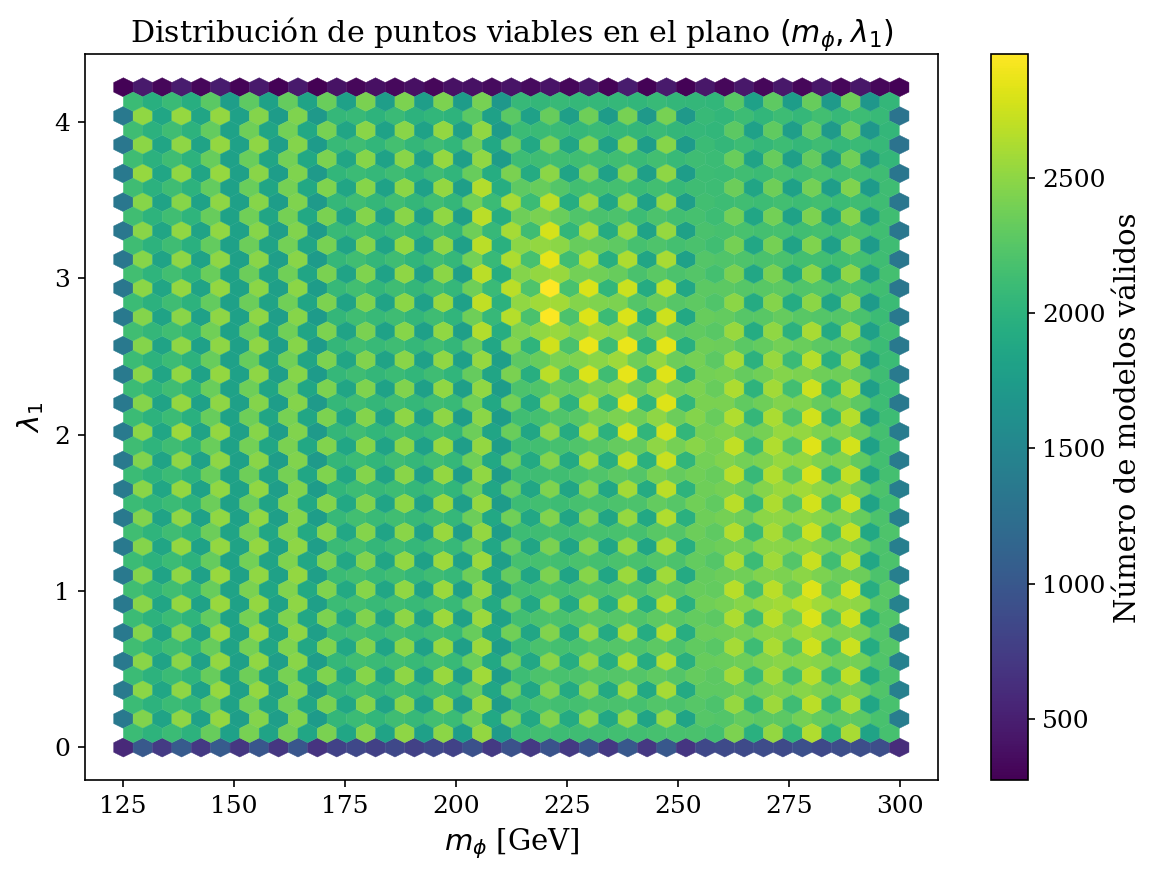

In [7]:
if len(df_valid) > 0:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Usamos hexbin para representar la densidad de puntos sin solapamiento masivo
    hb = ax.hexbin(
        df_valid['m_phi'], 
        df_valid['lam1'], 
        gridsize=40, 
        cmap='viridis', 
        mincnt=1,
        linewidths=0.2
    )
    
    cb = fig.colorbar(hb, ax=ax, label='Número de modelos válidos')
    ax.set_xlabel(r'$m_\phi$ [GeV]')
    ax.set_ylabel(r'$\lambda_1$')
    ax.set_title(r'Distribución de puntos viables en el plano $(m_\phi, \lambda_1)$')
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos suficientes para graficar.")

## 4. Impacto de la asimetría logarítmica: $\lambda_6$ vs $\tan\beta$
Evaluamos cómo las regiones de alta $\tan\beta$ ($\sim 10^4 - 10^5$) se correlacionan con la viabilidad del parámetro Z_2-breaking $\lambda_6$.

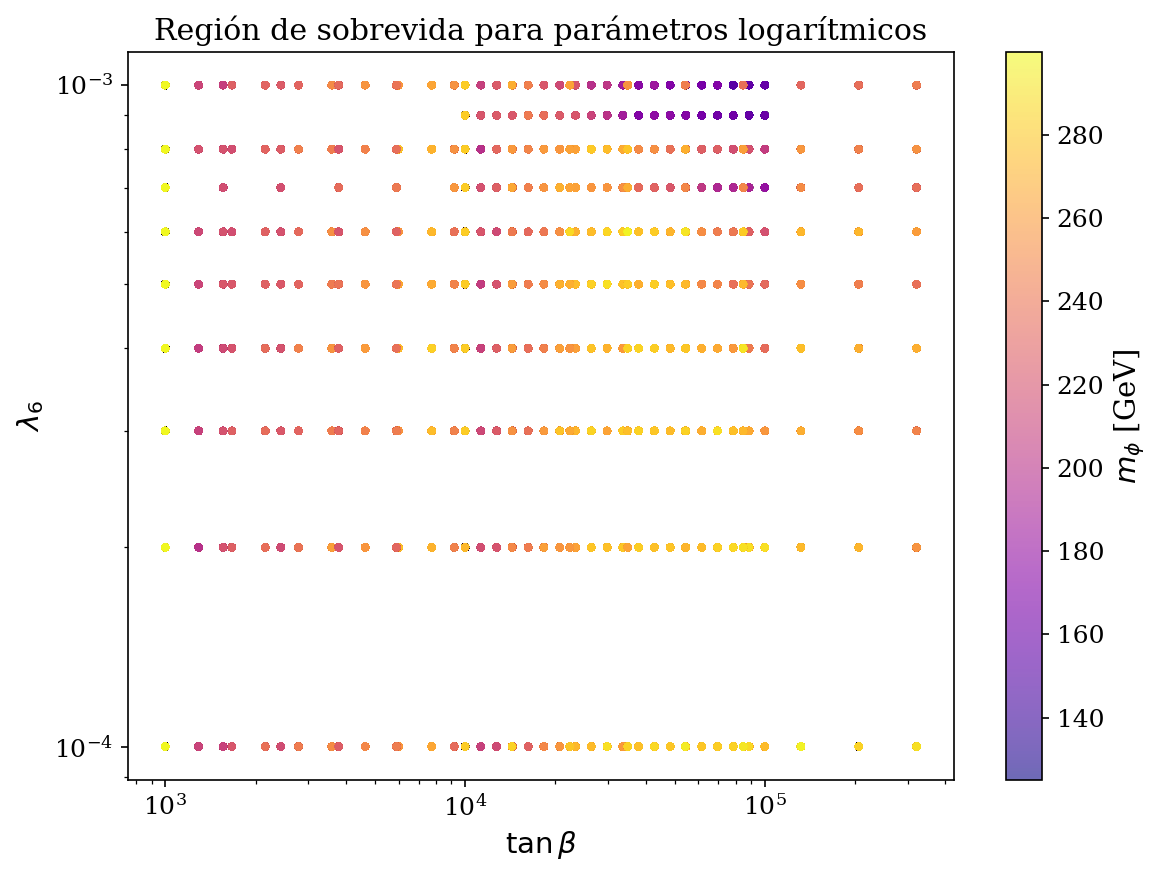

In [8]:
if len(df_valid) > 0:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Dado que los iteradores de la CLI eran logarítmicos, mapeamos los ejes en log
    sc = ax.scatter(
        df_valid['tan_beta'], 
        df_valid['lambda6'], 
        c=df_valid['m_phi'], # Usamos la masa como color para añadir dimensionalidad
        cmap='plasma', 
        alpha=0.6, 
        s=15,
        edgecolors='none'
    )
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    cb = fig.colorbar(sc, ax=ax, label=r'$m_\phi$ [GeV]')
    
    ax.set_xlabel(r'$\tan\beta$')
    ax.set_ylabel(r'$\lambda_6$')
    ax.set_title(r'Región de sobrevida para parámetros logarítmicos')
    
    plt.tight_layout()
    plt.show()

: 

: 

: 

: 

: 